# RetailAnalytics360 🛍️
### E-Commerce Customer Analytics and Sales Forecasting

Welcome to the **RetailAnalytics360** analytical notebook! This project is an applied data science project that walks through a complete data pipeline modeled after real-world online retailers. 

#### Objectives:
1. **Exploratory Data Analysis (EDA)**: Inspect e-commerce sales trends, demographic customer groupings, and revenue distribution.
2. **Customer Segmentation (RFM + K-Means)**: Group customers into action-oriented behavioral cohorts using K-Means Clustering on Recency, Frequency, and Monetary (RFM) values.
3. **Weekly Sales Forecasting (Random Forest)**: Build a recursive time-series forecast model using lag variables, rolling averages, and cyclical date features.
4. **Market Basket Analysis (Product Association)**: Find items frequently purchased together using Support, Confidence, and Lift rules to drive bundling strategies.

## 1. Environment Setup & Data Ingestion
We begin by importing necessary data science libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`) and reading the datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Set styles
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load data (adjusting path if running inside the notebooks directory)
data_dir = '../data' if os.path.exists('../data') else 'data'
customers = pd.read_csv(f'{data_dir}/customers.csv')
transactions = pd.read_csv(f'{data_dir}/transactions.csv')

print(f'Successfully loaded:')
print(f'- {len(customers):,} customer profiles')
print(f'- {len(transactions):,} transaction line-items')

Successfully loaded:
- 1,000 customer profiles
- 29,705 transaction line-items


## 2. Exploratory Data Analysis (EDA)
Before applying machine learning algorithms, let's explore customer demographics and high-level retail metrics.

C:\Users\user\AppData\Local\Temp\ipykernel_21016\3839745352.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customers, x='Gender', ax=axes[1], palette='Set2')


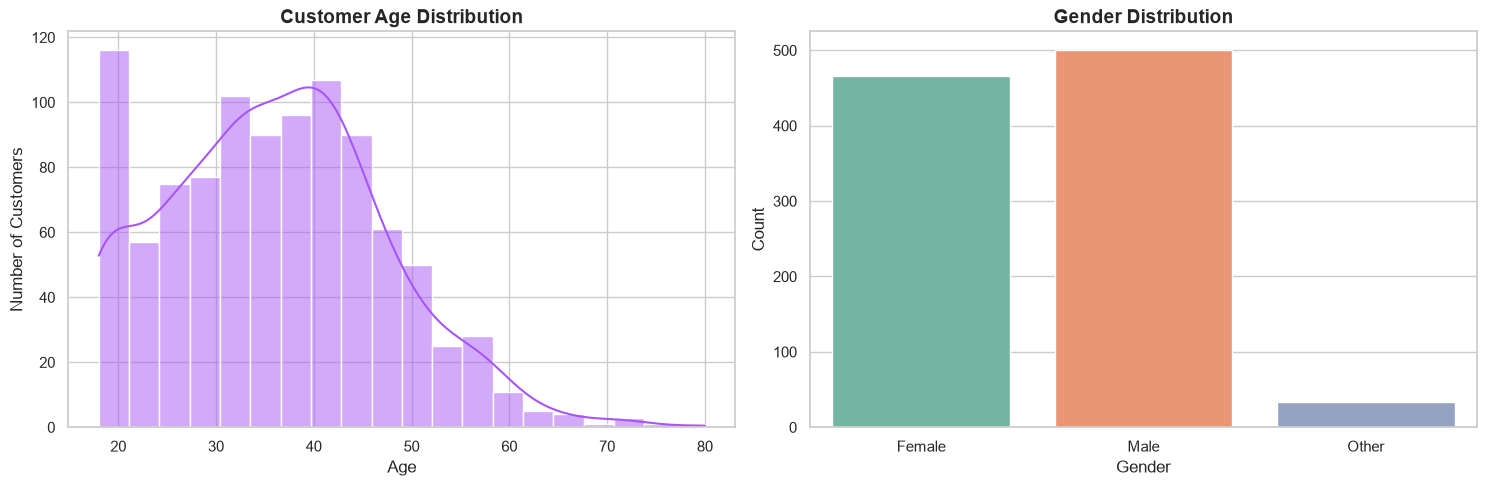

In [2]:
# Customer Age and Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(customers['Age'], bins=20, kde=True, ax=axes[0], color='#a855f7')
axes[0].set_title('Customer Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')

sns.countplot(data=customers, x='Gender', ax=axes[1], palette='Set2')
axes[1].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Monthly Revenue Trend
Let's aggregate transaction lines monthly and plot revenue performance over time.

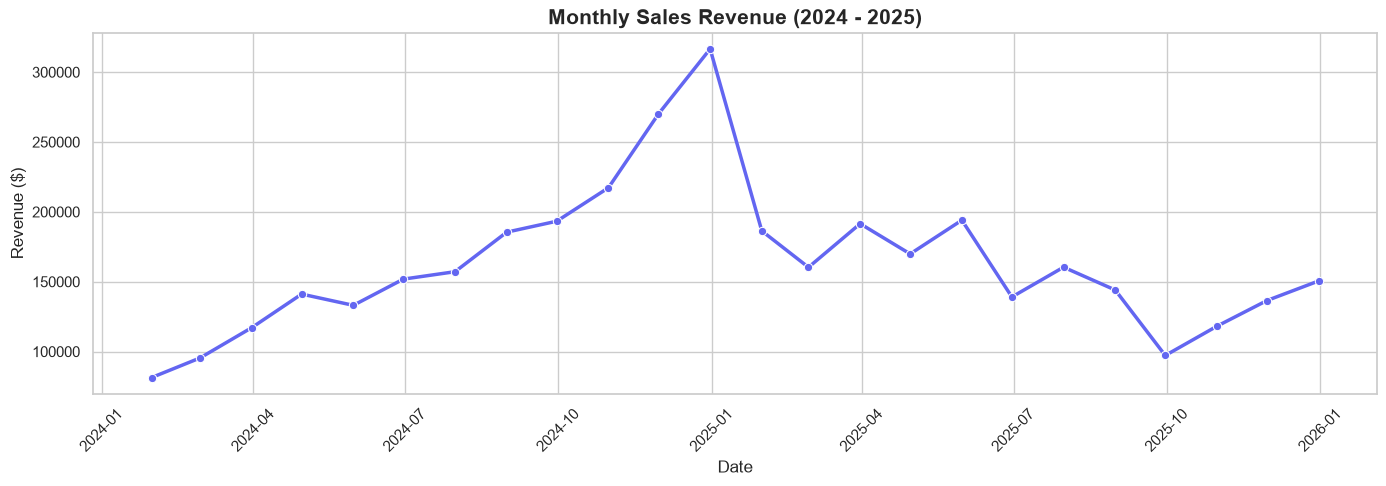

In [3]:
# Aggregate monthly sales
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])
monthly_sales = transactions.resample('ME', on='TransactionDate')['TotalRevenue'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_sales, x='TransactionDate', y='TotalRevenue', marker='o', color='#6366f1', linewidth=2.5)
plt.title('Monthly Sales Revenue (2024 - 2025)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Product Category Performance
Let's see which product category contributes most to our revenue and units sold.

C:\Users\user\AppData\Local\Temp\ipykernel_21016\3941384582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_perf, x='ProductCategory', y='TotalRevenue', ax=axes[0], palette='magma')
C:\Users\user\AppData\Local\Temp\ipykernel_21016\3941384582.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_perf, x='ProductCategory', y='UnitsSold', ax=axes[1], palette='viridis')


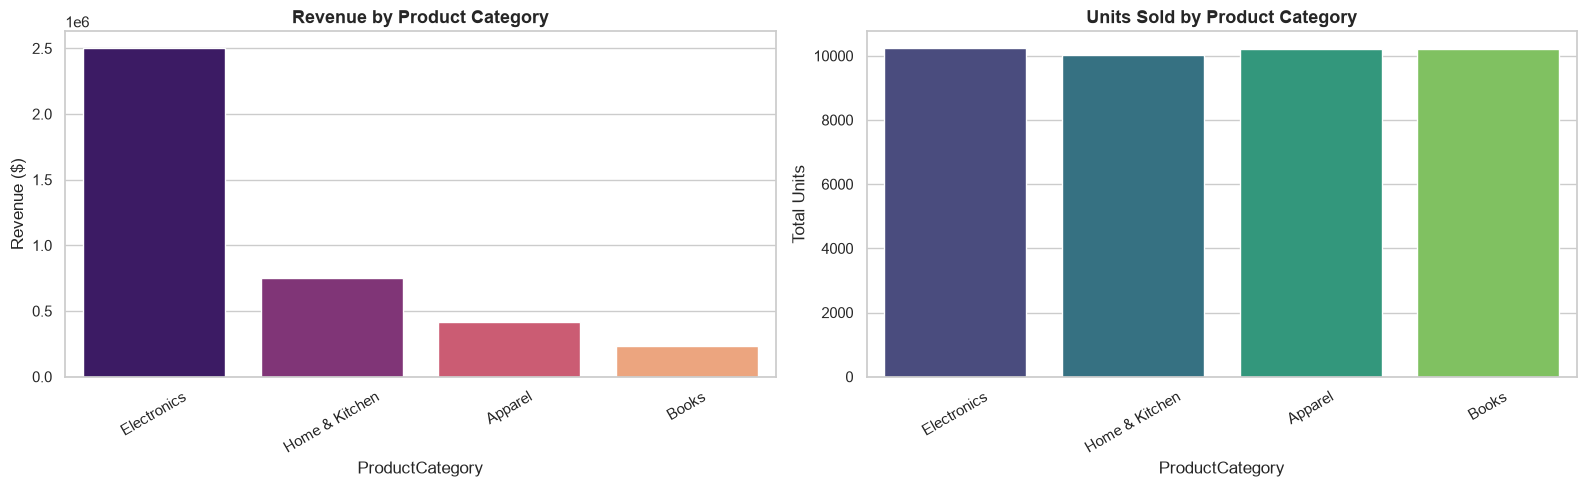

In [4]:
category_perf = transactions.groupby('ProductCategory').agg(
    TotalRevenue=('TotalRevenue', 'sum'),
    UnitsSold=('Quantity', 'sum'),
    AvgPrice=('UnitPrice', 'mean')
).reset_index().sort_values(by='TotalRevenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=category_perf, x='ProductCategory', y='TotalRevenue', ax=axes[0], palette='magma')
axes[0].set_title('Revenue by Product Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=category_perf, x='ProductCategory', y='UnitsSold', ax=axes[1], palette='viridis')
axes[1].set_title('Units Sold by Product Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Units')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 3. Customer Segmentation (RFM Analysis)
**RFM** stands for:
- **Recency**: Days since the customer's last purchase. (Lower is better)
- **Frequency**: How often they buy. (Higher is better)
- **Monetary Value**: The total money they spent. (Higher is better)

Let's calculate RFM metrics for each unique customer.

In [5]:
# Define reference date (1 day after last transaction)
ref_date = transactions['TransactionDate'].max() + pd.Timedelta(days=1)

# Compute RFM metrics
rfm = transactions.groupby('CustomerID').agg(
    Recency=('TransactionDate', lambda x: (ref_date - x.max()).days),
    Frequency=('TransactionID', 'nunique'),
    Monetary=('TotalRevenue', 'sum')
).reset_index()

print('Sample RFM Data:')
print(rfm.head())
print('\nDistribution Description:')
print(rfm.describe())

Sample RFM Data:
  CustomerID  Recency  Frequency  Monetary
0     C10000       66         17   3639.43
1     C10001      694          1     28.48
2     C10002      225          9    966.36
3     C10003       20         14   2349.05
4     C10004      142          6    568.62

Distribution Description:
          Recency   Frequency      Monetary
count  970.000000  970.000000    970.000000
mean   217.083505   11.715464   4028.713649
std    201.343778    9.633719   4467.297000
min      1.000000    1.000000      8.990000
25%     46.000000    5.000000    683.307500
50%    154.000000   10.000000   2673.725000
75%    346.750000   16.000000   5394.607500
max    731.000000   52.000000  26372.360000


### Log Transformation and Standardization
K-Means clustering relies on Euclidean distance. If the variables are heavily skewed or have widely different ranges (e.g., Recency ranges from 1 to 700, frequency from 1 to 50, and monetary from $20 to $5000), K-Means will bias heavily towards monetary values.

To fix this, we:
1. Apply **Log(x + 1)** transformation to normalize distributions.
2. Apply **Standard Scaling** to set their mean to 0 and variance to 1.

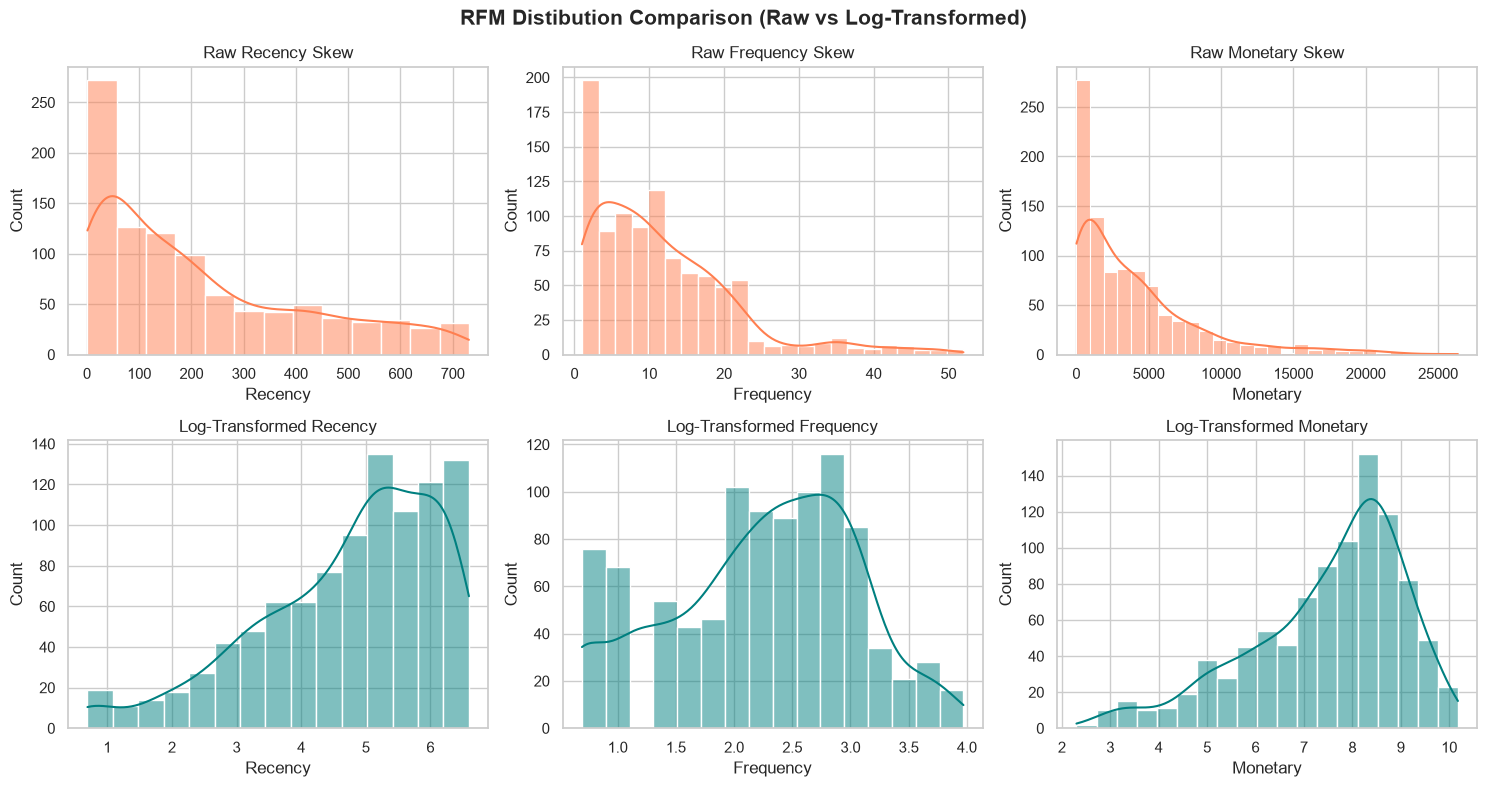

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Log transform to stabilize variance
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# Plot distributions before vs after log
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], kde=True, ax=axes[0, idx], color='coral')
    axes[0, idx].set_title(f'Raw {col} Skew')
    
    sns.histplot(rfm_log[col], kde=True, ax=axes[1, idx], color='teal')
    axes[1, idx].set_title(f'Log-Transformed {col}')

plt.suptitle('RFM Distibution Comparison (Raw vs Log-Transformed)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Elbow Method for Finding Optimal Clusters (K)
We test K from 1 to 8 and compute the Within-Cluster Sum of Squares (WCSS). We select the 'elbow point' where WCSS drop slows down.

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\user\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\user\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Python314\Lib\subprocess.py", line 555, in run
    with Popen(*popenargs, **kwargs)

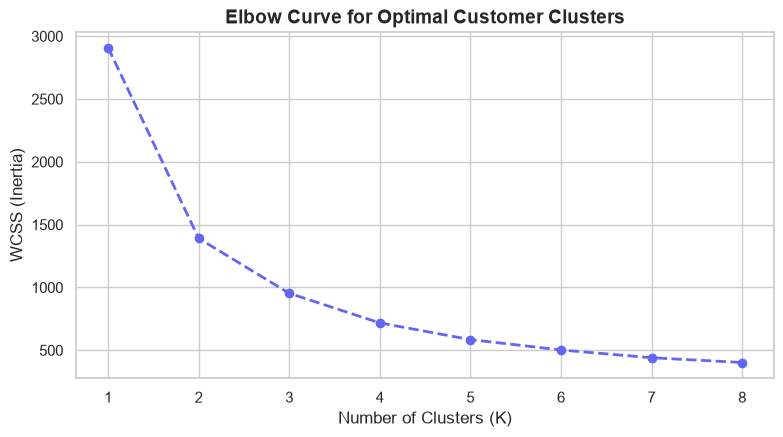

In [7]:
wcss = []
for i in range(1, 9):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 9), wcss, marker='o', ls='--', color='#6366f1', lw=2)
plt.title('Elbow Curve for Optimal Customer Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()

### Fitting K-Means (K = 4) and Profiling
Let's cluster the customers into 4 segments and profile their characteristics.

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Map cluster to profiles dynamically based on monetary averages
cluster_means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
sorted_clusters = cluster_means['Monetary'].sort_values(ascending=False).index.tolist()

segment_labels = {
    sorted_clusters[0]: 'VIP Spenders',
    sorted_clusters[1]: 'Loyal & Regular',
    sorted_clusters[2]: 'New / Casual',
    sorted_clusters[3]: 'At-Risk / Churned'
}

rfm['Segment'] = rfm['Cluster'].map(segment_labels)

# Show segment stats
cohort_summary = rfm.groupby('Segment').agg(
    CustomerCount=('CustomerID', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean')
).reset_index()

print(cohort_summary)

             Segment  CustomerCount  AvgRecency  AvgFrequency  AvgMonetary
0  At-Risk / Churned            152  502.881579      1.697368   170.557961
1    Loyal & Regular            318  164.625786     17.279874  6189.717075
2       New / Casual            296  264.689189      5.979730  1326.748818
3       VIP Spenders            204   16.833333     18.828431  7455.292892


### Visualizing Cohort Averages

C:\Users\user\AppData\Local\Temp\ipykernel_21016\1649623358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cohort_summary, x='Segment', y='AvgRecency', ax=axes[0], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_21016\1649623358.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
C:\Users\user\AppData\Local\Temp\ipykernel_21016\1649623358.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cohort_summary, x='Segment', y='AvgFrequency', ax=axes[1], palette='Set2')
C:\Users\user\AppDat

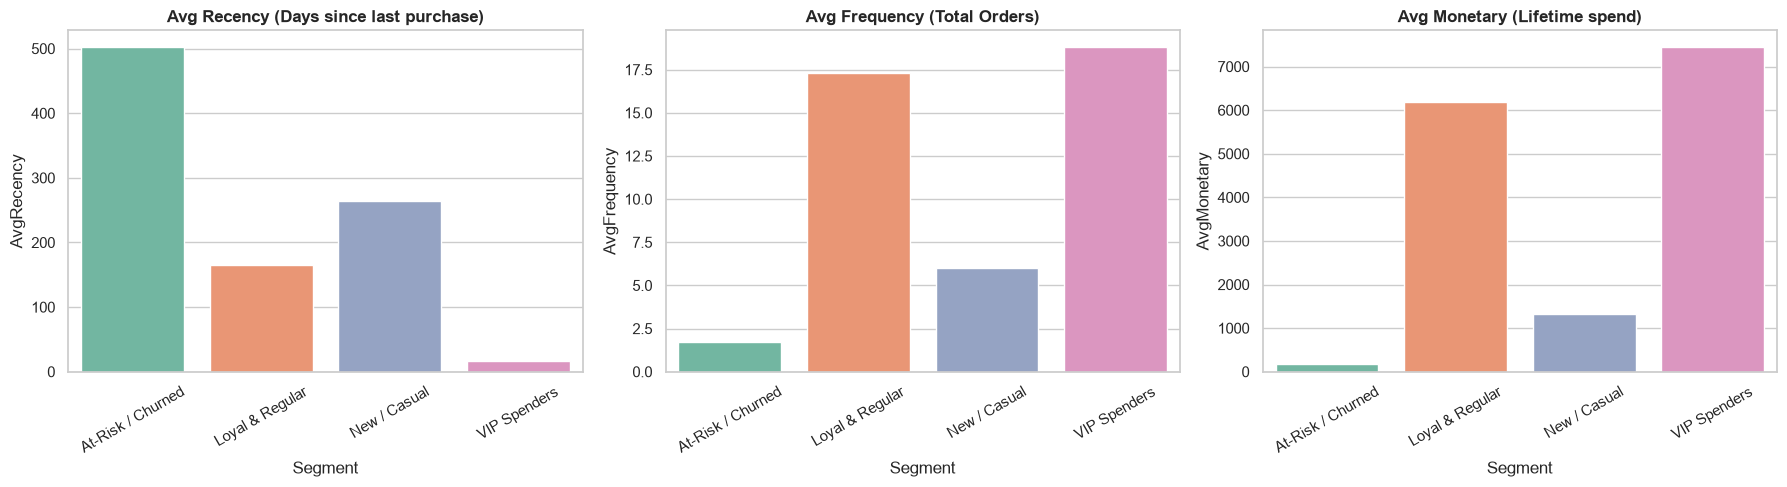

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=cohort_summary, x='Segment', y='AvgRecency', ax=axes[0], palette='Set2')
axes[0].set_title('Avg Recency (Days since last purchase)', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

sns.barplot(data=cohort_summary, x='Segment', y='AvgFrequency', ax=axes[1], palette='Set2')
axes[1].set_title('Avg Frequency (Total Orders)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

sns.barplot(data=cohort_summary, x='Segment', y='AvgMonetary', ax=axes[2], palette='Set2')
axes[2].set_title('Avg Monetary (Lifetime spend)', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## 4. Weekly Sales Forecasting (Time-Series ML)
Next, we aggregate e-commerce transactions weekly and train a **Random Forest Regressor** to forecast future revenue.

### Feature Engineering:
- **Lag Features**: Past sales volume from Lag 1, Lag 2, Lag 3, and Lag 4 weeks.
- **Rolling window**: 4-week historical moving average and standard deviation.
- **Cyclical date features**: Sine/Cosine transformation of the week index to represent annual seasonal patterns.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Aggregate Weekly Sales
weekly_sales = transactions.resample('W-MON', on='TransactionDate')['TotalRevenue'].sum().reset_index()
weekly_sales.columns = ['Week', 'Revenue']

# 2. Compute Lags
df_feat = weekly_sales.copy()
for lag in range(1, 5):
    df_feat[f'Revenue_Lag_{lag}'] = df_feat['Revenue'].shift(lag)
    
# 3. Compute Rolling statistics
df_feat['Rolling_Mean_4W'] = df_feat['Revenue_Lag_1'].rolling(window=4).mean()
df_feat['Rolling_Std_4W'] = df_feat['Revenue_Lag_1'].rolling(window=4).std()

# 4. Calendar details
df_feat['Week_of_Year'] = df_feat['Week'].dt.isocalendar().week.astype(float)
df_feat['Month'] = df_feat['Week'].dt.month
df_feat['Year'] = df_feat['Week'].dt.year
df_feat['Week_Sin'] = np.sin(2 * np.pi * df_feat['Week_of_Year'] / 52.18)
df_feat['Week_Cos'] = np.cos(2 * np.pi * df_feat['Week_of_Year'] / 52.18)

# Drop null rows
df_feat = df_feat.dropna().reset_index(drop=True)
print(f'Feature Matrix shape: {df_feat.shape}')
print(df_feat.head(3))

Feature Matrix shape: (102, 13)
        Week   Revenue  Revenue_Lag_1  Revenue_Lag_2  Revenue_Lag_3  \
0 2024-01-29  21221.77       20543.97       16475.33       14561.86   
1 2024-02-05  17479.70       21221.77       20543.97       16475.33   
2 2024-02-12  19661.07       17479.70       21221.77       20543.97   

   Revenue_Lag_4  Rolling_Mean_4W  Rolling_Std_4W  Week_of_Year  Month  Year  \
0        4270.81       13962.9925     6926.233908           5.0      1  2024   
1       14561.86       18200.7325     3206.027470           6.0      2  2024   
2       16475.33       18930.1925     2308.382092           7.0      2  2024   

   Week_Sin  Week_Cos  
0  0.566348  0.824166  
1  0.661249  0.750167  
2  0.746573  0.665304  


### Train-Test Split (Chronological) & Model Training
We set aside the last 8 weeks of data as our validation set to test prediction accuracy, and fit a Random Forest model.

In [11]:
test_size = 8
train_df = df_feat.iloc[:-test_size]
test_df = df_feat.iloc[-test_size:]

feature_cols = [
    'Revenue_Lag_1', 'Revenue_Lag_2', 'Revenue_Lag_3', 'Revenue_Lag_4',
    'Rolling_Mean_4W', 'Rolling_Std_4W',
    'Week_Sin', 'Week_Cos', 'Month', 'Year'
]

X_train, y_train = train_df[feature_cols], train_df['Revenue']
X_test, y_test = test_df[feature_cols], test_df['Revenue']

# Fit Random Forest
rf_model = RandomForestRegressor(n_estimators=150, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
preds = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f'Random Forest Evaluation Metrics:')
print(f'- R2 Score (Fit Quality): {r2:.3f}')
print(f'- Mean Absolute Error: ${mae:,.2f}')

Random Forest Evaluation Metrics:
- R2 Score (Fit Quality): -1.095
- Mean Absolute Error: $8,901.29


### Out-of-Sample Recursive Forecasting
To forecast into the future, we run a **recursive multi-step forecast**. Each predicted value is fed back in as the next lag feature (`Revenue_Lag_1`) for subsequent steps.

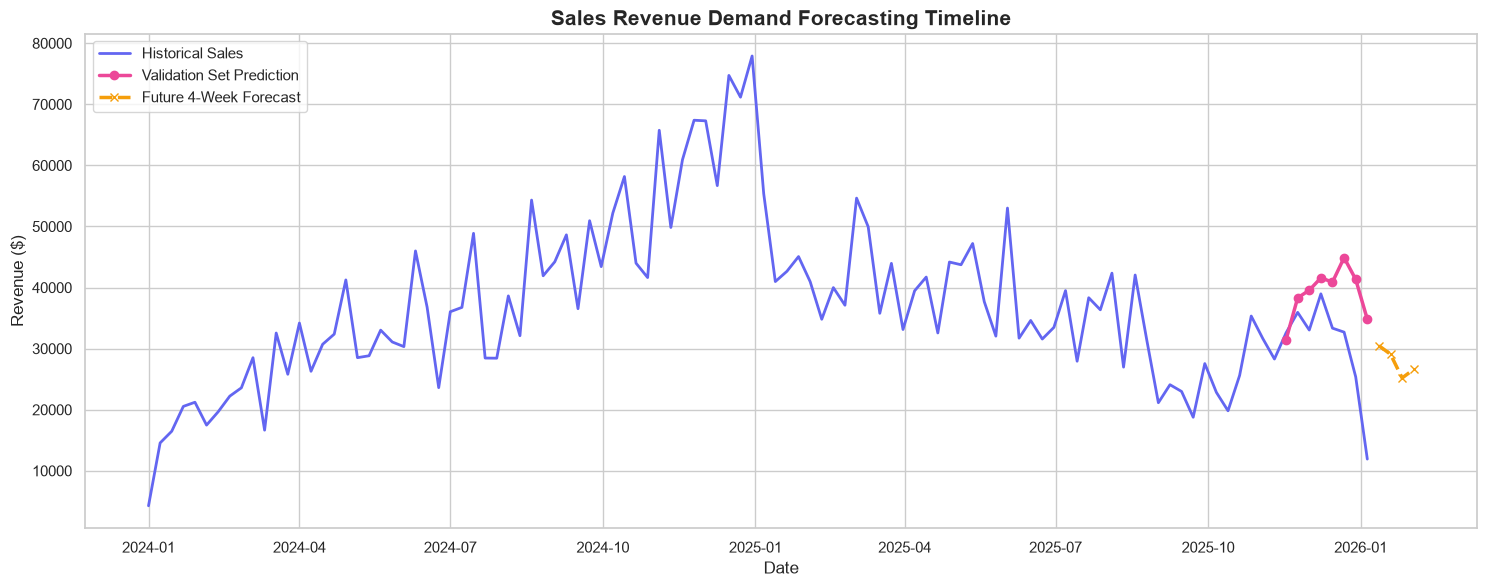

In [12]:
future_forecasts = []
future_weeks = []

last_row = df_feat.iloc[-1].copy()
current_week = last_row['Week']

# Buffer
lags_buffer = [
    last_row['Revenue'],
    last_row['Revenue_Lag_1'],
    last_row['Revenue_Lag_2'],
    last_row['Revenue_Lag_3']
]
rolling_buffer = df_feat['Revenue'].tail(4).tolist()

for i in range(4):
    next_week = current_week + pd.Timedelta(weeks=1)
    next_week_of_year = next_week.isocalendar().week
    next_month = next_week.month
    next_year = next_week.year
    
    # Calculate sinusoids
    w_sin = np.sin(2 * np.pi * next_week_of_year / 52.18)
    w_cos = np.cos(2 * np.pi * next_week_of_year / 52.18)
    
    # Rolling stats
    roll_mean = np.mean(rolling_buffer)
    roll_std = np.std(rolling_buffer) if len(rolling_buffer) > 1 else 0.0
    
    feat_vector = pd.DataFrame([[
        lags_buffer[0], lags_buffer[1], lags_buffer[2], lags_buffer[3],
        roll_mean, roll_std,
        w_sin, w_cos, next_month, next_year
    ]], columns=feature_cols)
    
    predicted_rev = rf_model.predict(feat_vector)[0]
    future_forecasts.append(predicted_rev)
    future_weeks.append(next_week)
    
    # Shift buffers
    lags_buffer = [predicted_rev] + lags_buffer[:-1]
    rolling_buffer = rolling_buffer[1:] + [predicted_rev]
    current_week = next_week

# Visualizing Historical, Validation actuals vs predictions, and Future forecasts
plt.figure(figsize=(15, 6))
plt.plot(weekly_sales['Week'], weekly_sales['Revenue'], label='Historical Sales', color='#6366f1', lw=2)
plt.plot(test_df['Week'], preds, label='Validation Set Prediction', color='#ec4899', marker='o', lw=2.5)
plt.plot(future_weeks, future_forecasts, label='Future 4-Week Forecast', color='#f59e0b', marker='x', ls='--', lw=2.5)
plt.title('Sales Revenue Demand Forecasting Timeline', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 5. Market Basket Analysis (MBA)
We identify product relationships using transaction baskets.
**Support**: Probability of purchasing item A and item B together.
**Confidence**: Probability that a buyer gets B given they purchased A.
**Lift**: How much more likely B is bought *because* of A, relative to B's baseline popularity. A Lift > 1.0 indicates positive correlation.

In [13]:
from collections import Counter
from itertools import combinations

# Group products by transaction (basket of items)
baskets = transactions.groupby('TransactionID')['ProductName'].apply(list).reset_index()
total_transactions = len(baskets)

# Compute support for single products
prod_counts = transactions.groupby('ProductName')['TransactionID'].nunique()
prod_support = (prod_counts / total_transactions).to_dict()

# Compute support for pairs
pair_counts = Counter()
for items in baskets['ProductName']:
    unique_items = sorted(list(set(items)))
    for combo in combinations(unique_items, 2):
        pair_counts[combo] += 1

# Calculate association rules metrics
rules = []
for pair, count in pair_counts.items():
    prodA, prodB = pair
    support = count / total_transactions
    
    # A -> B
    confA_B = support / prod_support[prodA]
    liftA_B = confA_B / prod_support[prodB]
    
    # B -> A
    confB_A = support / prod_support[prodB]
    liftB_A = confB_A / prod_support[prodA]
    
    rules.append({
        'Antecedent': prodA, 'Consequent': prodB, 
        'Support': support, 'Confidence': confA_B, 'Lift': liftA_B, 'Count': count
    })
    rules.append({
        'Antecedent': prodB, 'Consequent': prodA, 
        'Support': support, 'Confidence': confB_A, 'Lift': liftB_A, 'Count': count
    })

df_rules = pd.DataFrame(rules).sort_values(by='Lift', ascending=False).reset_index(drop=True)
print('Top 10 Product Associations by Lift:')
print(df_rules.head(10)[['Antecedent', 'Consequent', 'Support', 'Confidence', 'Lift', 'Count']])

Top 10 Product Associations by Lift:
       Antecedent      Consequent   Support  Confidence      Lift  Count
0  Sci-Fi Trilogy   Fiction Novel  0.052886    0.356254  2.923081    601
1   Fiction Novel  Sci-Fi Trilogy  0.052886    0.433935  2.923081    601
2    Coffee Maker         Toaster  0.049630    0.439252  2.897077    564
3         Toaster    Coffee Maker  0.049630    0.327336  2.897077    564
4          Hoodie         T-Shirt  0.029039    0.223577  1.994295    330
5         T-Shirt          Hoodie  0.029039    0.259027  1.994295    330
6         T-Shirt           Socks  0.029919    0.266876  1.966783    340
7           Socks         T-Shirt  0.029919    0.220493  1.966783    340
8          Laptop        Keyboard  0.032119    0.267399  1.937963    365
9        Keyboard          Laptop  0.032119    0.232781  1.937963    365


## 6. Strategic Takeaways & Business Action Plan
1. **Customer Retention**: High-value cohorts (`VIP Spenders`) contribute significantly to margins. Loyalty campaigns must target them. At-risk clients should be auto-routed to win-back coupons.
2. **Logistics Optimization**: The recursive Random Forest Weekly Demand Forecast flags upcoming peaks and valleys, guiding inventory levels and staffing schedules.
3. **Cross-Selling & Recommendations**: High-lift associations (such as `Coffee Maker` and `Toaster`, or `Fiction Novel` and `Sci-Fi Trilogy`) highlight opportunities for discount bundling, smart store layout placing, and digital cart suggestion algorithms.